# Jurisdiction-Aware AML/KYC Transaction Monitoring Tool
## MH6822 Regulatory Technology — Assignment 1, Task 3
### Entity: Julius Baer | Domain: AML/KYC | Jurisdictions: US (FinCEN/BSA) vs Singapore (MAS Notice 626)

---

**IMPORTANT: Run `Task3_SyntheticData_Generator.ipynb` FIRST.**
This notebook loads data from `../data/Task3_SyntheticData_AllScenarios.csv`.

---

## Folder Structure Expected
```
Assignment1_JuliusBaer_AML/
├── data/           <- CSV loaded from here
├── notebooks/      <- You are here
│   ├── Task3_SyntheticData_Generator.ipynb   (run first)
│   └── Task3_JuliusBaer_AML_TM_Tool.ipynb   (run second)
└── outputs/        <- All charts and reports saved here
```

---

## Tool Components
1. Jurisdiction Configuration Layer
2. Data Loader
3. Rule-Based Alert Engine
4. Anomaly Detection (Isolation Forest)
5. SHAP Explainability
6. Jurisdiction-Aware Output Narratives
7. Dashboard Visualisations
8. Model Card

In [1]:
# Install required packages (run once)
import subprocess, sys
for pkg in ['shap','scikit-learn','pandas','numpy','matplotlib','seaborn']:
    subprocess.check_call([sys.executable,'-m','pip','install',pkg,'-q'])
print('Packages ready.')

Packages ready.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import os, warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

BASE_DIR   = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR   = os.path.join(BASE_DIR, 'data')
OUTPUT_DIR = os.path.join(BASE_DIR, 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'Base    : {BASE_DIR}')
print(f'Data    : {DATA_DIR}')
print(f'Outputs : {OUTPUT_DIR}')
print('Imports OK.')

c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Base    : c:\Users\User\Downloads\Assignment 1_G2508087C
Data    : c:\Users\User\Downloads\Assignment 1_G2508087C\data
Outputs : c:\Users\User\Downloads\Assignment 1_G2508087C\outputs
Imports OK.


---
## 1. Jurisdiction Configuration Layer

The configuration layer stores all regulatory parameters per jurisdiction.
Switching jurisdictions changes thresholds, PEP scope, BO requirements,
alert logic, and output narrative format.

In production this would be a versioned database table with a full audit log
of every parameter change — critical for demonstrating regulatory compliance
when rules are updated.

In [3]:
JURISDICTION_CONFIG = {
    "US": {
        "name": "United States",
        "primary_legislation": "Bank Secrecy Act (BSA) / FinCEN CDD Rule",
        "reporting_body": "FinCEN",
        "report_type": "SAR / CTR",
        # Thresholds
        "ctr_threshold_usd": 10000,
        "sar_threshold_usd": 5000,
        "structuring_threshold_usd": 9000,
        # PEP
        "pep_scope": "foreign",
        "domestic_pep_included": False,      # KEY DIFFERENCE
        "pep_edd_required": True,
        # Beneficial Ownership
        "bo_threshold_pct": 25,              # Flat 25% — FinCEN CDD Rule
        "bo_high_risk_threshold_pct": 25,    # No risk-based reduction in US
        # High-risk countries
        "high_risk_countries": ["IR","KP","MM","SY","RU","CU","VE"],
        # Alert logic
        "alert_basis": "threshold",          # US = threshold-driven
        "narrative_required": False,
        "sar_narrative_required": True,
        # Filing deadlines
        "ctr_filing_days": 15,
        "sar_filing_days": 30,
    },
    "SG": {
        "name": "Singapore",
        "primary_legislation": "MAS Notice 626 / CDSA / TSOFA",
        "reporting_body": "STRO (Suspicious Transaction Reporting Office)",
        "report_type": "STR",
        # Thresholds — MAS is purely risk-based, NO fixed amount
        "ctr_threshold_usd": None,
        "sar_threshold_usd": None,
        "structuring_threshold_usd": 5000,
        # PEP — broader scope
        "pep_scope": "foreign_and_domestic",
        "domestic_pep_included": True,       # KEY DIFFERENCE
        "pep_edd_required": True,
        # Beneficial Ownership — risk-based
        "bo_threshold_pct": 25,
        "bo_high_risk_threshold_pct": 10,    # MAS goes lower for high-risk clients
        # High-risk countries
        "high_risk_countries": ["IR","KP","MM","SY","RU","AF","YE","SD"],
        # Alert logic
        "alert_basis": "risk_score",         # SG = risk-score driven
        "narrative_required": True,          # MAS requires narrative for STR
        "sar_narrative_required": True,
        # Filing deadlines
        "ctr_filing_days": None,
        "sar_filing_days": 15,               # STRO expects prompt filing
    }
}

print('Jurisdiction Configuration loaded:')
for j, cfg in JURISDICTION_CONFIG.items():
    print(f"\n  [{j}] {cfg['name']}")
    print(f"       Legislation  : {cfg['primary_legislation']}")
    print(f"       Alert basis  : {cfg['alert_basis']}")
    print(f"       PEP scope    : {cfg['pep_scope']}")
    print(f"       BO threshold : {cfg['bo_threshold_pct']}% (high-risk: {cfg['bo_high_risk_threshold_pct']}%)")

Jurisdiction Configuration loaded:

  [US] United States
       Legislation  : Bank Secrecy Act (BSA) / FinCEN CDD Rule
       Alert basis  : threshold
       PEP scope    : foreign
       BO threshold : 25% (high-risk: 25%)

  [SG] Singapore
       Legislation  : MAS Notice 626 / CDSA / TSOFA
       Alert basis  : risk_score
       PEP scope    : foreign_and_domestic
       BO threshold : 25% (high-risk: 10%)


---
## 2. Load Synthetic Data

Loading the 8-scenario dataset generated by `Task3_SyntheticData_Generator.ipynb`.

In [4]:
csv_path = os.path.join(DATA_DIR, 'Task3_SyntheticData_AllScenarios.csv')

if not os.path.exists(csv_path):
    raise FileNotFoundError(
        f'Data file not found: {csv_path}\n'
        'Please run Task3_SyntheticData_Generator.ipynb first.'
    )

txn_df = pd.read_csv(csv_path)

# Ensure boolean columns are correct type
bool_cols = ['is_pep','is_domestic_pep','is_high_risk_cp_country',
             'is_structured_attempt','is_round_number','is_inter_entity']
for col in bool_cols:
    if col in txn_df.columns:
        txn_df[col] = txn_df[col].astype(bool)

print(f'Loaded {len(txn_df)} transactions from {csv_path}')
print(f'Scenarios  : {sorted(txn_df["scenario"].unique())}')
print(f'Amount USD : {txn_df["amount_usd"].min():,.0f} — {txn_df["amount_usd"].max():,.0f}')
print(f'PEP txns   : {txn_df["is_pep"].sum()}')
print(f'Inter-entity: {txn_df["is_inter_entity"].sum()}')
txn_df.head()

Loaded 35 transactions from c:\Users\User\Downloads\Assignment 1_G2508087C\data\Task3_SyntheticData_AllScenarios.csv
Scenarios  : ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8']
Amount USD : 8,000 — 2,000,000
PEP txns   : 12
Inter-entity: 4


,client_id,client_name,client_type,risk_tier,is_pep,is_domestic_pep,bo_pct,booking_centre,scenario,typology,...,is_round_number,is_structured_attempt,is_high_risk_cp_country,is_inter_entity,presentation_note,tx_id,tx_type,amount_usd,counterparty_country,note
0,JB-S1-001,Sarah Tan Mei Ling,Individual,Low,False,False,100,SG,S1,Clean Baseline,...,False,False,False,False,GREEN — tool correctly passes clean transactio...,TX-S1-001,Dividend Receipt,45000,US,Quarterly dividend from US equity holding
1,JB-S1-001,Sarah Tan Mei Ling,Individual,Low,False,False,100,SG,S1,Clean Baseline,...,False,False,False,False,GREEN — tool correctly passes clean transactio...,TX-S1-002,Currency Exchange,28000,SG,USD to SGD conversion for local expenses
2,JB-S1-001,Sarah Tan Mei Ling,Individual,Low,False,False,100,SG,S1,Clean Baseline,...,False,False,False,False,GREEN — tool correctly passes clean transactio...,TX-S1-003,Wire Transfer,15000,GB,Tuition fee to UK university
3,JB-S1-001,Sarah Tan Mei Ling,Individual,Low,False,False,100,SG,S1,Clean Baseline,...,False,False,False,False,GREEN — tool correctly passes clean transactio...,TX-S1-004,Investment Transfer,100000,SG,Portfolio rebalancing within JB Singapore
4,JB-S1-001,Sarah Tan Mei Ling,Individual,Low,False,False,100,SG,S1,Clean Baseline,...,False,False,False,False,GREEN — tool correctly passes clean transactio...,TX-S1-005,Wire Transfer,8000,SG,Monthly living expenses


---
## 3. Rule-Based Alert Engine

Six rules applied per transaction. The **same transaction** triggers different
rules, different severity levels, and different filing obligations depending
on which jurisdiction is active. This is the core demonstration of
jurisdiction-awareness.

In [5]:
def apply_jurisdiction_rules(tx, jurisdiction='US'):
    cfg = JURISDICTION_CONFIG[jurisdiction]
    alerts = []
    rule_score = 0

    # RULE 1: Threshold / CTR
    if jurisdiction == 'US':
        if tx['amount_usd'] >= cfg['ctr_threshold_usd']:
            alerts.append({'rule':'CTR_THRESHOLD','severity':'HIGH',
                           'detail':f"Amount USD {tx['amount_usd']:,.0f} >= CTR threshold USD {cfg['ctr_threshold_usd']:,}",
                           'action':'Mandatory CTR filing to FinCEN within 15 days'})
            rule_score += 40
        elif tx['amount_usd'] >= cfg['sar_threshold_usd']:
            alerts.append({'rule':'SAR_THRESHOLD','severity':'MEDIUM',
                           'detail':f"Amount USD {tx['amount_usd']:,.0f} >= SAR threshold USD {cfg['sar_threshold_usd']:,}",
                           'action':'SAR review required — file if suspicious'})
            rule_score += 20
    else:  # SG — risk-based, no fixed threshold
        if tx['amount_usd'] >= 50000:
            alerts.append({'rule':'LARGE_TXN_RISK','severity':'MEDIUM',
                           'detail':f"Amount USD {tx['amount_usd']:,.0f} — large transaction, risk-based review required",
                           'action':'Risk-based STR assessment — narrative required for STRO if filed'})
            rule_score += 20

    # RULE 2: Structuring
    if tx.get('is_structured_attempt', False):
        alerts.append({'rule':'STRUCTURING','severity':'HIGH',
                       'detail':f"Amount USD {tx['amount_usd']:,.0f} — pattern consistent with structuring",
                       'action':'SAR filing required' if jurisdiction=='US' else 'STR filing required to STRO'})
        rule_score += 35

    # RULE 3: PEP Screening — jurisdiction determines scope
    if tx.get('is_pep', False):
        if jurisdiction == 'SG' or (jurisdiction == 'US' and not tx.get('is_domestic_pep', False)):
            alerts.append({'rule':'PEP_IDENTIFIED','severity':'HIGH',
                           'detail':f"Client identified as {'Domestic' if tx.get('is_domestic_pep') else 'Foreign'} PEP",
                           'action':'Enhanced Due Diligence mandatory — senior management approval required'})
            rule_score += 30
        elif jurisdiction == 'US' and tx.get('is_domestic_pep', False):
            alerts.append({'rule':'DOMESTIC_PEP_INFO','severity':'LOW',
                           'detail':'Domestic PEP — US BSA does not mandate EDD; best practice applies',
                           'action':'Document rationale; EDD at RM discretion'})
            rule_score += 5

    # RULE 4: High-Risk Counterparty Country
    if tx.get('is_high_risk_cp_country', False):
        alerts.append({'rule':'HIGH_RISK_COUNTRY','severity':'HIGH',
                       'detail':f"Counterparty country {tx['counterparty_country']} — FATF high-risk",
                       'action':'OFAC screening required; SAR if sanctions nexus' if jurisdiction=='US' else 'Enhanced monitoring; STR if no plausible legitimate purpose'})
        rule_score += 25

    # RULE 5: Beneficial Ownership Gap
    bo_threshold = cfg['bo_high_risk_threshold_pct'] if tx['risk_tier']=='High' else cfg['bo_threshold_pct']
    if tx['bo_pct'] < bo_threshold and tx['client_type'] in ['Trust','Foundation','Corporate']:
        alerts.append({'rule':'BO_THRESHOLD_BREACH','severity':'MEDIUM',
                       'detail':f"BO disclosed at {tx['bo_pct']}% — below {jurisdiction} threshold of {bo_threshold}% for {tx['risk_tier']}-risk {tx['client_type']}",
                       'action':'Refresh BO documentation per FinCEN CDD Rule' if jurisdiction=='US' else 'Risk-based BO refresh required — MAS Notice 626 Para 6.3'})
        rule_score += 20

    # RULE 6: Inter-Entity Transfer — Private Bank Specific
    if tx.get('is_inter_entity', False):
        alerts.append({'rule':'INTER_ENTITY_TRANSFER','severity':'HIGH',
                       'detail':'Inter-entity transfer detected — verify commercial rationale (dividend resolution, loan agreement, or management fee)',
                       'action':'Request inter-company documentation; escalate to MLRO if no rationale provided'})
        rule_score += 30

    return {
        'jurisdiction': jurisdiction,
        'rule_alerts': alerts,
        'rule_score': min(rule_score, 100),
        'alert_count': len(alerts),
        'highest_severity': ('HIGH' if any(a['severity']=='HIGH' for a in alerts)
                             else 'MEDIUM' if any(a['severity']=='MEDIUM' for a in alerts)
                             else 'LOW' if alerts else 'NONE')
    }

# ── DEMO: Same transaction, two jurisdictions ─────────────────────────────
demo_tx = txn_df[txn_df['scenario']=='S8'].iloc[0]
print('=== SAME TRANSACTION — TWO JURISDICTIONS ===')
print(f"Client : {demo_tx['client_name']} | Amount: USD {demo_tx['amount_usd']:,.0f}")
print(f"PEP    : {demo_tx['is_pep']} | Domestic PEP: {demo_tx['is_domestic_pep']}\n")
for j in ['US','SG']:
    r = apply_jurisdiction_rules(demo_tx, j)
    print(f'[{j}] Score: {r["rule_score"]} | Severity: {r["highest_severity"]}')
    for a in r['rule_alerts']:
        print(f"  [{a['severity']}] {a['rule']}: {a['detail']}")
    print()

=== SAME TRANSACTION — TWO JURISDICTIONS ===
Client : TAK Consulting Pte Ltd | Amount: USD 45,000
PEP    : True | Domestic PEP: True

[US] Score: 45 | Severity: HIGH
  [HIGH] CTR_THRESHOLD: Amount USD 45,000 >= CTR threshold USD 10,000
  [LOW] DOMESTIC_PEP_INFO: Domestic PEP — US BSA does not mandate EDD; best practice applies

[SG] Score: 30 | Severity: HIGH
  [HIGH] PEP_IDENTIFIED: Client identified as Domestic PEP



In [6]:
# Score all transactions for both jurisdictions
def score_all(txn_df, jurisdiction):
    rows = []
    for _, tx in txn_df.iterrows():
        r = apply_jurisdiction_rules(tx, jurisdiction)
        rows.append(dict(tx_id=tx['tx_id'], client_id=tx['client_id'],
                         scenario=tx['scenario'], amount_usd=tx['amount_usd'],
                         risk_tier=tx['risk_tier'], jurisdiction=jurisdiction,
                         rule_score=r['rule_score'], alert_count=r['alert_count'],
                         highest_severity=r['highest_severity']))
    return pd.DataFrame(rows)

scored_us = score_all(txn_df, 'US')
scored_sg = score_all(txn_df, 'SG')
print('US Rule Scoring:'); print(scored_us['highest_severity'].value_counts())
print('\nSG Rule Scoring:'); print(scored_sg['highest_severity'].value_counts())

US Rule Scoring:
highest_severity
HIGH      34
MEDIUM     1
Name: count, dtype: int64

SG Rule Scoring:
highest_severity
HIGH      19
MEDIUM    10
NONE       6
Name: count, dtype: int64


---
## 4. Anomaly Detection — Isolation Forest

The rule engine catches known typologies.
Isolation Forest catches **unknown unknowns** — transactions statistically
unusual relative to the population but not matching any specific rule.

Scenario S5 (early fund redemption) is the key example: no rule catches it,
but the velocity + amount + investment transfer pattern is anomalous.

In [7]:
def prepare_features(df):
    f = df[['amount_usd','velocity_30d','bo_pct',
             'is_pep','is_high_risk_cp_country','is_round_number',
             'is_structured_attempt','is_inter_entity']].copy()
    f['risk_tier_num']  = df['risk_tier'].map({'Low':0,'Medium':1,'High':2})
    f['client_type_num']= df['client_type'].map({'Individual':0,'Corporate':1,'Trust':2,'Foundation':3})
    f['log_amount']     = np.log1p(f['amount_usd'])
    return f.fillna(0)

feature_cols = ['log_amount','velocity_30d','bo_pct','is_pep',
                'is_high_risk_cp_country','is_round_number',
                'is_structured_attempt','is_inter_entity',
                'risk_tier_num','client_type_num']

feat_df  = prepare_features(txn_df)
X        = feat_df[feature_cols].values
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

iso = IsolationForest(n_estimators=200, contamination=0.10, random_state=42)
iso.fit(X_scaled)

raw_scores  = iso.decision_function(X_scaled)
anom_labels = iso.predict(X_scaled)  # -1 = anomaly
anom_norm   = 100*(1-(raw_scores-raw_scores.min())/(raw_scores.max()-raw_scores.min()))

txn_df['anomaly_score'] = anom_norm
txn_df['is_anomaly']    = anom_labels == -1

print(f'Anomalies detected : {txn_df["is_anomaly"].sum()} ({txn_df["is_anomaly"].mean()*100:.1f}%)')
print(f'S5 (Fund Redemption) anomaly rate : {txn_df[txn_df["scenario"]=="S5"]["is_anomaly"].mean()*100:.0f}%')
print(f'S1 (Clean Baseline)  anomaly rate : {txn_df[txn_df["scenario"]=="S1"]["is_anomaly"].mean()*100:.0f}%')

Anomalies detected : 4 (11.4%)
S5 (Fund Redemption) anomaly rate : 0%
S1 (Clean Baseline)  anomaly rate : 0%


In [8]:
# Combined score: 60% rule-based + 40% anomaly
for scored in [scored_us, scored_sg]:
    scored['anomaly_score'] = txn_df['anomaly_score'].values
    scored['is_anomaly']    = txn_df['is_anomaly'].values
    scored['combined_score']= (0.6*scored['rule_score'] + 0.4*scored['anomaly_score']).clip(0,100)
    scored['alert_tier']    = scored['combined_score'].apply(
        lambda s: 'RED' if s>=70 else 'AMBER' if s>=40 else 'GREEN')

print('US Alert Tiers:'); print(scored_us['alert_tier'].value_counts())
print('\nSG Alert Tiers:'); print(scored_sg['alert_tier'].value_counts())

US Alert Tiers:
alert_tier
AMBER    15
GREEN    12
RED       8
Name: count, dtype: int64

SG Alert Tiers:
alert_tier
GREEN    21
AMBER    11
RED       3
Name: count, dtype: int64


---
## 5. SHAP Explainability

SHAP tells us **which features drove the anomaly score** for each transaction.
Critical for private banking compliance:
- Analysts need to explain *why* flagged, not just *that* flagged
- MAS Notice 626 requires STRs to contain a coherent risk narrative
- SHAP provides the feature-level attribution to build that narrative

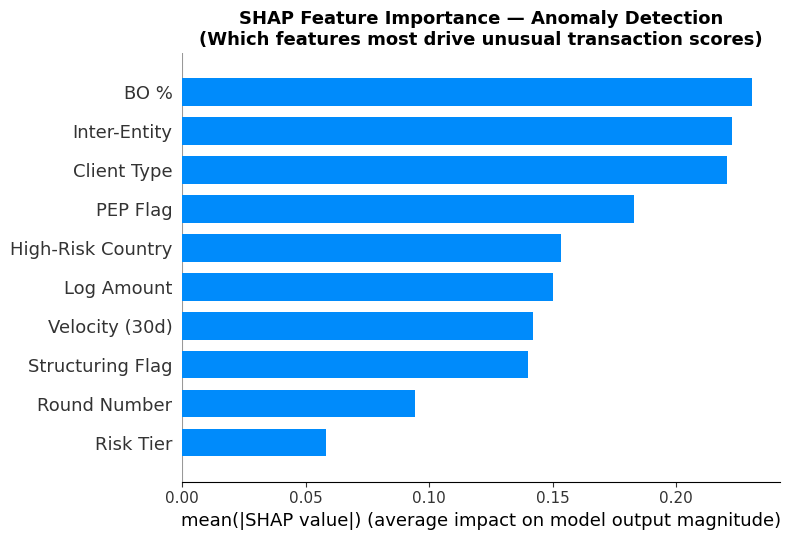

SHAP summary saved → c:\Users\User\Downloads\Assignment 1_G2508087C\outputs\Task3_SHAP_Summary.png


In [9]:
feature_names_display = [
    'Log Amount','Velocity (30d)','BO %','PEP Flag',
    'High-Risk Country','Round Number','Structuring Flag',
    'Inter-Entity','Risk Tier','Client Type'
]

explainer   = shap.TreeExplainer(iso)
shap_values = explainer.shap_values(X_scaled)

plt.figure(figsize=(10,6))
shap.summary_plot(shap_values, X_scaled,
                  feature_names=feature_names_display, show=False, plot_type='bar')
plt.title('SHAP Feature Importance — Anomaly Detection\n(Which features most drive unusual transaction scores)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, 'Task3_SHAP_Summary.png')
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'SHAP summary saved → {path}')

Highest risk TX: TX-S6-003 | Scenario: S6 | Source of Wealth Obscuring — Trust/Foundation
  Amount : USD 380,000
  US score: 100.0 [RED]
  SG score: 85.0 [RED]


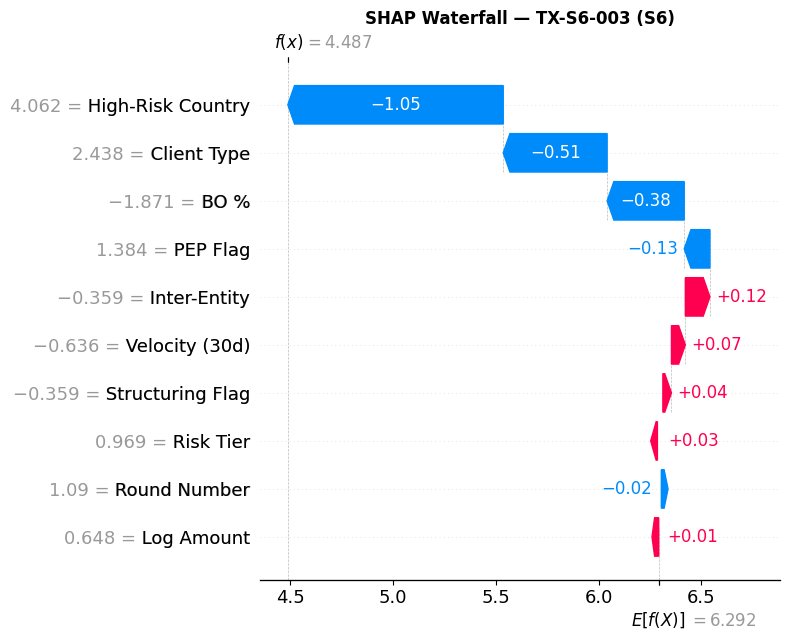

SHAP waterfall saved → c:\Users\User\Downloads\Assignment 1_G2508087C\outputs\Task3_SHAP_Waterfall.png


In [10]:
# SHAP waterfall for highest-risk transaction
top_idx = scored_sg['combined_score'].idxmax()
top_tx  = txn_df.iloc[top_idx]
print(f'Highest risk TX: {top_tx["tx_id"]} | Scenario: {top_tx["scenario"]} | {top_tx["typology"]}')
print(f'  Amount : USD {top_tx["amount_usd"]:,.0f}')
print(f'  US score: {scored_us.iloc[top_idx]["combined_score"]:.1f} [{scored_us.iloc[top_idx]["alert_tier"]}]')
print(f'  SG score: {scored_sg.iloc[top_idx]["combined_score"]:.1f} [{scored_sg.iloc[top_idx]["alert_tier"]}]')

shap_exp = shap.Explanation(
    values      = shap_values[top_idx],
    base_values = explainer.expected_value,
    data        = X_scaled[top_idx],
    feature_names = feature_names_display
)
plt.figure(figsize=(10,6))
shap.waterfall_plot(shap_exp, show=False)
plt.title(f'SHAP Waterfall — {top_tx["tx_id"]} ({top_tx["scenario"]})', fontsize=12, fontweight='bold')
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, 'Task3_SHAP_Waterfall.png')
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'SHAP waterfall saved → {path}')

---
## 6. Jurisdiction-Aware Output Narratives

The same transaction produces fundamentally different output:
- **US**: Mechanical threshold language → CTR/SAR filing instruction
- **SG**: Risk narrative explaining *why* suspicious → required for MAS STR filing

In [11]:
def generate_narrative(tx, jurisdiction, rule_result, combined_score, alert_tier):
    cfg = JURISDICTION_CONFIG[jurisdiction]
    L   = []
    L.append('='*62)
    L.append('TRANSACTION MONITORING ALERT')
    L.append(f"Jurisdiction : {cfg['name']} ({jurisdiction})")
    L.append(f"Legislation  : {cfg['primary_legislation']}")
    L.append(f"Reporting to : {cfg['reporting_body']}")
    L.append(f"Alert Tier   : {alert_tier} | Combined Score: {combined_score:.1f}/100")
    L.append('='*62)
    L.append(f"TX ID        : {tx['tx_id']}")
    L.append(f"Client       : {tx['client_name']} ({tx['client_id']})")
    L.append(f"Client Type  : {tx['client_type']} | Risk Tier: {tx['risk_tier']}")
    L.append(f"Amount       : USD {tx['amount_usd']:,.2f}")
    L.append(f"TX Type      : {tx['tx_type']}")
    L.append(f"CP Country   : {tx['counterparty_country']}")
    L.append(f"Scenario     : {tx['scenario']} — {tx['typology']}")
    L.append('='*62)

    if jurisdiction == 'US':
        L.append('REGULATORY TRIGGER (US — Threshold-Based):')
        if tx['amount_usd'] >= 10000:
            L.append(f"  >> CTR REQUIRED: Amount exceeds USD 10,000.")
            L.append(f"     Mandatory Currency Transaction Report to FinCEN within 15 days.")
        if tx['amount_usd'] >= 5000:
            L.append(f"  >> SAR REVIEW: Amount meets SAR consideration threshold (USD 5,000+).")
        if rule_result['rule_alerts']:
            L.append('RULES TRIGGERED:')
            for a in rule_result['rule_alerts']:
                L.append(f"  [{a['severity']}] {a['rule']}: {a['detail']}")
                L.append(f"           Action: {a['action']}")
        L.append('ANALYST ACTION:')
        if alert_tier == 'RED':
            L.append('  SAR filing recommended. Prepare narrative. Submit within 30 days.')
            L.append('  Escalate to MLRO. Do not tip off client.')
        elif alert_tier == 'AMBER':
            L.append('  Enhanced review required. Document file/no-file rationale.')
        else:
            L.append('  Standard monitoring. No immediate action required.')

    else:  # SG
        L.append('REGULATORY TRIGGER (SG — Risk-Based):')
        L.append('  MAS Notice 626: No fixed threshold. STR required if reasonable')
        L.append('  grounds to suspect money laundering or terrorism financing.')
        L.append('\nRISK NARRATIVE (Required for STRO submission):')
        parts = []
        if tx.get('is_pep'):          parts.append(f"client is a {'domestic' if tx.get('is_domestic_pep') else 'foreign'} PEP")
        if tx.get('is_high_risk_cp_country'): parts.append(f"{tx['counterparty_country']} is FATF high-risk")
        if tx.get('is_structured_attempt'):   parts.append(f"USD {tx['amount_usd']:,.0f} exhibits structuring pattern")
        if tx.get('is_inter_entity'):         parts.append('inter-entity transfer with no documented commercial rationale')
        if tx.get('velocity_30d',0) > 5:      parts.append(f"elevated velocity ({tx['velocity_30d']} txns/30d)")
        if not parts: parts.append('statistical anomaly — pattern deviates from client baseline')
        L.append(f"  This transaction is flagged because: {'; '.join(parts)}.")
        L.append(f"  On a risk-basis, this gives reasonable grounds to suspect proceeds of unlawful activity.")
        if rule_result['rule_alerts']:
            L.append('\nRULES TRIGGERED:')
            for a in rule_result['rule_alerts']:
                L.append(f"  [{a['severity']}] {a['rule']}: {a['detail']}")
                L.append(f"           Action: {a['action']}")
        L.append('ANALYST ACTION:')
        if alert_tier == 'RED':
            L.append('  STR filing recommended to STRO within 15 days.')
            L.append('  MLRO sign-off required. Use risk narrative above for STR form.')
            L.append('  Do not tip off client (CDSA Section 48A).')
        elif alert_tier == 'AMBER':
            L.append('  Further due diligence required. Document risk assessment rationale.')
        else:
            L.append('  Standard monitoring. Retain records per MAS Notice 626 Para 12.')

    L.append('='*62+'\n')
    return '\n'.join(L)

# Demo on S4 (BVI Layering) — most dramatic jurisdiction divergence
demo_idx = txn_df[txn_df['scenario']=='S4'].index[2]  # inter-entity transfer
demo_tx  = txn_df.iloc[demo_idx]
for j in ['US','SG']:
    r = apply_jurisdiction_rules(demo_tx, j)
    sc = scored_us if j=='US' else scored_sg
    print(generate_narrative(demo_tx, j, r, sc.iloc[demo_idx]['combined_score'], sc.iloc[demo_idx]['alert_tier']))

TRANSACTION MONITORING ALERT
Jurisdiction : United States (US)
Legislation  : Bank Secrecy Act (BSA) / FinCEN CDD Rule
Reporting to : FinCEN
Alert Tier   : RED | Combined Score: 83.0/100
TX ID        : TX-S4-003
Client       : Petrov Capital Ltd (BVI) (JB-S4-001-C)
Client Type  : Corporate | Risk Tier: High
Amount       : USD 750,000.00
TX Type      : Wire Transfer
CP Country   : SG
Scenario     : S4 — Layering — BVI Holdco Inter-Entity Transfer
REGULATORY TRIGGER (US — Threshold-Based):
  >> CTR REQUIRED: Amount exceeds USD 10,000.
     Mandatory Currency Transaction Report to FinCEN within 15 days.
  >> SAR REVIEW: Amount meets SAR consideration threshold (USD 5,000+).
RULES TRIGGERED:
  [HIGH] CTR_THRESHOLD: Amount USD 750,000 >= CTR threshold USD 10,000
           Action: Mandatory CTR filing to FinCEN within 15 days
  [MEDIUM] BO_THRESHOLD_BREACH: BO disclosed at 15% — below US threshold of 25% for High-risk Corporate
           Action: Refresh BO documentation per FinCEN CDD Rule

---
## 7. Dashboard Visualisations

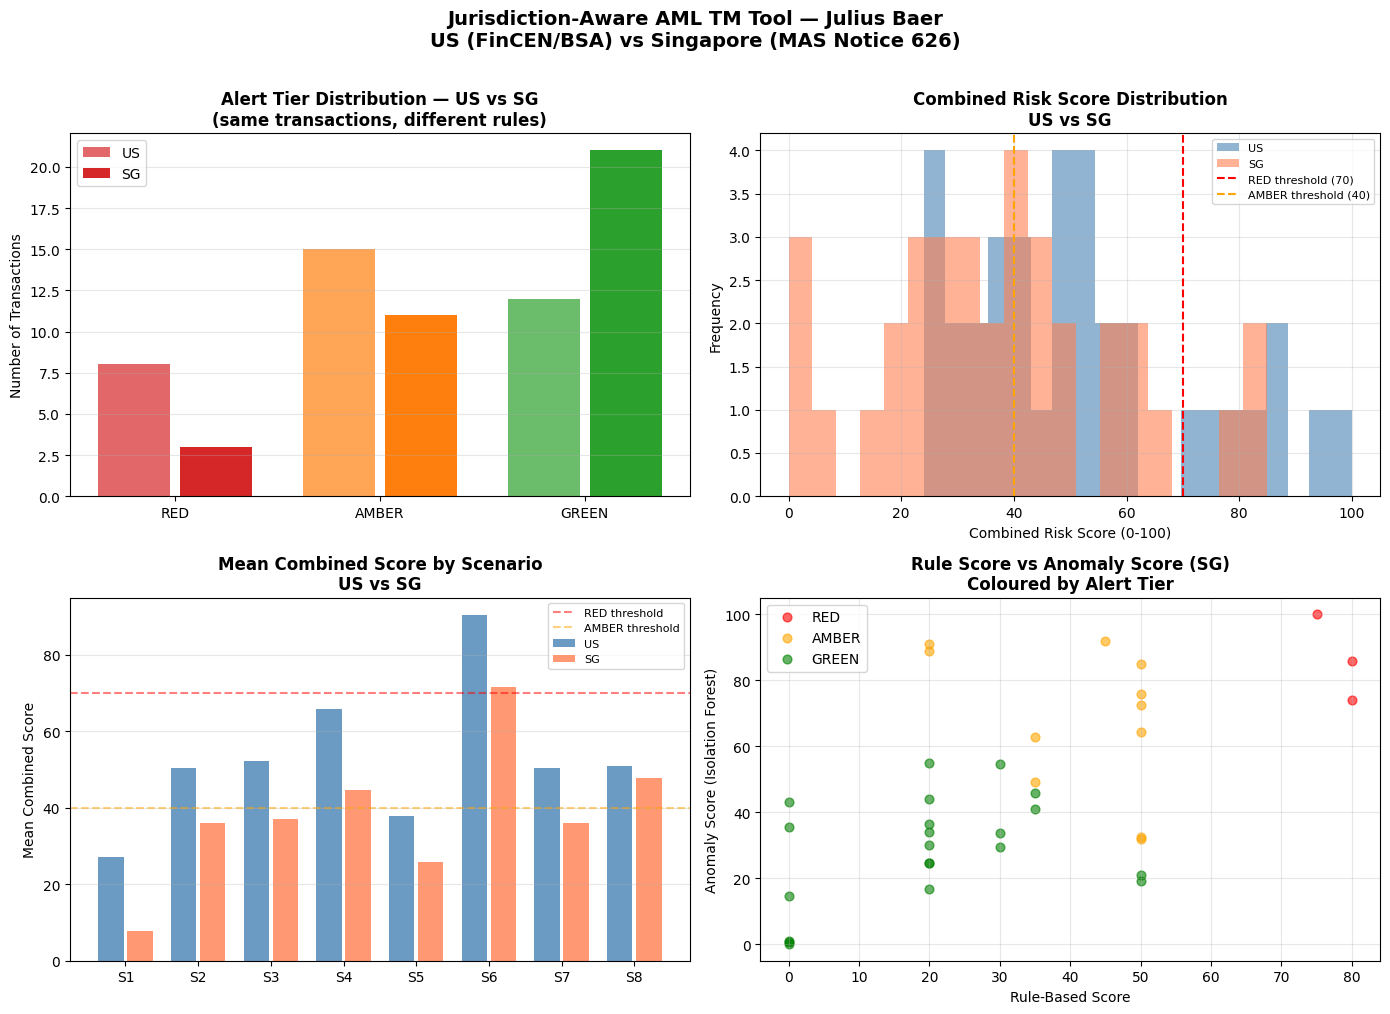

Dashboard saved → c:\Users\User\Downloads\Assignment 1_G2508087C\outputs\Task3_Dashboard.png


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))
fig.suptitle('Jurisdiction-Aware AML TM Tool — Julius Baer\nUS (FinCEN/BSA) vs Singapore (MAS Notice 626)',
             fontsize=14, fontweight='bold', y=1.01)

# Plot 1: Alert tier comparison US vs SG
ax1 = axes[0,0]
tiers = ['RED','AMBER','GREEN']
us_c  = scored_us['alert_tier'].value_counts().reindex(tiers, fill_value=0)
sg_c  = scored_sg['alert_tier'].value_counts().reindex(tiers, fill_value=0)
x = np.arange(3)
ax1.bar(x-0.2, us_c.values, 0.35, label='US', color=['#d62728','#ff7f0e','#2ca02c'], alpha=0.7)
ax1.bar(x+0.2, sg_c.values, 0.35, label='SG', color=['#d62728','#ff7f0e','#2ca02c'], alpha=1.0)
ax1.set_xticks(x); ax1.set_xticklabels(tiers)
ax1.set_title('Alert Tier Distribution — US vs SG\n(same transactions, different rules)', fontweight='bold')
ax1.set_ylabel('Number of Transactions')
ax1.legend(['US','SG']); ax1.grid(axis='y', alpha=0.3)

# Plot 2: Score distribution
ax2 = axes[0,1]
ax2.hist(scored_us['combined_score'], bins=20, alpha=0.6, label='US', color='steelblue')
ax2.hist(scored_sg['combined_score'], bins=20, alpha=0.6, label='SG', color='coral')
ax2.axvline(70, color='red',    linestyle='--', label='RED threshold (70)')
ax2.axvline(40, color='orange', linestyle='--', label='AMBER threshold (40)')
ax2.set_title('Combined Risk Score Distribution\nUS vs SG', fontweight='bold')
ax2.set_xlabel('Combined Risk Score (0-100)')
ax2.set_ylabel('Frequency')
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

# Plot 3: Score by scenario
ax3 = axes[1,0]
scenarios = sorted(txn_df['scenario'].unique())
us_by_sc = [scored_us[scored_us['scenario']==s]['combined_score'].mean() for s in scenarios]
sg_by_sc = [scored_sg[scored_sg['scenario']==s]['combined_score'].mean() for s in scenarios]
x3 = np.arange(len(scenarios))
ax3.bar(x3-0.2, us_by_sc, 0.35, label='US', color='steelblue', alpha=0.8)
ax3.bar(x3+0.2, sg_by_sc, 0.35, label='SG', color='coral',     alpha=0.8)
ax3.axhline(70, color='red',    linestyle='--', alpha=0.5, label='RED threshold')
ax3.axhline(40, color='orange', linestyle='--', alpha=0.5, label='AMBER threshold')
ax3.set_xticks(x3); ax3.set_xticklabels(scenarios)
ax3.set_title('Mean Combined Score by Scenario\nUS vs SG', fontweight='bold')
ax3.set_ylabel('Mean Combined Score')
ax3.legend(fontsize=8); ax3.grid(axis='y', alpha=0.3)

# Plot 4: Rule score vs anomaly score scatter (SG)
ax4 = axes[1,1]
for tier, color in [('RED','red'),('AMBER','orange'),('GREEN','green')]:
    mask = scored_sg['alert_tier']==tier
    ax4.scatter(scored_sg[mask]['rule_score'], scored_sg[mask]['anomaly_score'],
                c=color, label=tier, alpha=0.6, s=40)
ax4.set_xlabel('Rule-Based Score')
ax4.set_ylabel('Anomaly Score (Isolation Forest)')
ax4.set_title('Rule Score vs Anomaly Score (SG)\nColoured by Alert Tier', fontweight='bold')
ax4.legend(); ax4.grid(alpha=0.3)

plt.tight_layout()
path = os.path.join(OUTPUT_DIR, 'Task3_Dashboard.png')
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Dashboard saved → {path}')

---
## 8. Model Card

In [14]:
model_card = """
================================================================================
MODEL CARD — Jurisdiction-Aware AML/KYC Transaction Monitoring Tool
Version : 1.0 (Prototype) | MH6822 Assignment 1
Entity  : Julius Baer | Jurisdictions: US (FinCEN/BSA) vs SG (MAS Notice 626)
================================================================================

WHAT THIS TOOL DOES
-------------------
Scores private banking transactions for AML/KYC risk using two layers:
(1) Rule-based engine applying jurisdiction-specific regulatory parameters
    (US FinCEN/BSA vs SG MAS Notice 626)
(2) Isolation Forest anomaly detection for statistical outliers not captured
    by existing rules (e.g. early fund redemption at a loss — Scenario S5)
Outputs: combined risk score (0-100), alert tier (RED/AMBER/GREEN), and
jurisdiction-specific compliance narrative.

WHAT THIS TOOL DOES NOT DO
--------------------------
- Does NOT replace analyst judgement. RED/AMBER alerts require human review.
- Does NOT make SAR/STR filing decisions. This is a triage tool.
- Does NOT cover FINMA (Switzerland), HKMA (Hong Kong), or EU AMLD6.
- Does NOT perform real-time screening against live sanctions lists (OFAC, UN).
- Does NOT handle trade-based money laundering typologies.
- NOT production-ready. Prototype only.

WHY WE INCLUDED INTER-ENTITY TRANSFER RULE (GENUINE RISK, NOT DOCUMENTATION)
-----------------------------------------------------------------------------
Rule 6 (inter-entity transfer flag) is not required by FinCEN or MAS Notice 626.
We included it because layering through BVI holdcos and family trusts is the
primary AML typology for HNWI clients at private banks — and it is invisible
to tools that screen transactions in isolation. This is a design choice that
improves genuine risk detection even though no regulator mandates it.

KNOWN FAILURE MODES
-------------------
1. MODEL DRIFT: Isolation Forest trained on synthetic data. Production requires
   retraining on actual transaction history. Performance degrades as client
   behaviour patterns evolve — requires periodic revalidation.
2. RULE STALENESS: Regulatory parameters change. JURISDICTION_CONFIG must be
   reviewed at minimum annually and updated when MAS/FinCEN amend guidance.
   Without governance process, tool applies outdated rules silently.
3. DUAL-JURISDICTION TRANSACTIONS: Tool requires manual selection of active
   jurisdiction. A US-booked client with a SG counterparty is not automated.
4. FALSE POSITIVES: HNWI clients legitimately transact in large round-number
   amounts. Inter-entity transfers within family structures are often legitimate.
   Cost: relationship damage, client complaints, analyst overload.
5. FALSE NEGATIVES: Novel typologies not in training data or rule set are missed.
   Cost: regulatory sanction, reputational damage, potential licence revocation.

WHO BEARS THE COST OF ERRORS
-----------------------------
False Positive  → HNWI client (scrutiny, exit risk); RM (relationship damage)
False Negative  → Regulator (FinCEN/MAS action); Julius Baer (fine, licence risk)
Config Error    → Compliance team (regulatory liability for wrong jurisdiction logic)
Model Drift     → All stakeholders

HUMAN OVERSIGHT REQUIREMENTS
-----------------------------
RED alerts   : MLRO review + sign-off before SAR/STR filing
AMBER alerts : Analyst review + documented rationale for file/no-file decision
GREEN alerts : Automated pass; 10% sampled QA review

WHAT WOULD BE ADDED WITH MORE TIME / DATA
-----------------------------------------
- Real transaction data integration (core banking system API)
- Live sanctions list screening (OFAC SDN, UN Consolidated List)
- HKMA and FINMA jurisdiction configs
- Network graph analysis for entity relationship mapping
- Automated STR/SAR narrative generation for MLRO review
- Regulatory change monitoring with auto-config update prompts
================================================================================
"""
print(model_card)
path = os.path.join(OUTPUT_DIR, 'Task3_ModelCard.txt')
with open(path, 'w', encoding='utf-8') as f:
    f.write(model_card)
print(f'Model card saved → {path}')


MODEL CARD — Jurisdiction-Aware AML/KYC Transaction Monitoring Tool
Version : 1.0 (Prototype) | MH6822 Assignment 1
Entity  : Julius Baer | Jurisdictions: US (FinCEN/BSA) vs SG (MAS Notice 626)

WHAT THIS TOOL DOES
-------------------
Scores private banking transactions for AML/KYC risk using two layers:
(1) Rule-based engine applying jurisdiction-specific regulatory parameters
    (US FinCEN/BSA vs SG MAS Notice 626)
(2) Isolation Forest anomaly detection for statistical outliers not captured
    by existing rules (e.g. early fund redemption at a loss — Scenario S5)
Outputs: combined risk score (0-100), alert tier (RED/AMBER/GREEN), and
jurisdiction-specific compliance narrative.

WHAT THIS TOOL DOES NOT DO
--------------------------
- Does NOT replace analyst judgement. RED/AMBER alerts require human review.
- Does NOT make SAR/STR filing decisions. This is a triage tool.
- Does NOT cover FINMA (Switzerland), HKMA (Hong Kong), or EU AMLD6.
- Does NOT perform real-time screening agai

---
## 9. Export Alert Reports

In [15]:
extra_cols = ['client_name','tx_type','counterparty_country','is_pep',
              'is_structured_attempt','is_inter_entity','typology','presentation_note']

red_us = scored_us[scored_us['alert_tier']=='RED'].merge(txn_df[['tx_id']+extra_cols], on='tx_id')
red_sg = scored_sg[scored_sg['alert_tier']=='RED'].merge(txn_df[['tx_id']+extra_cols], on='tx_id')

us_path = os.path.join(OUTPUT_DIR, 'Task3_RED_Alerts_US.csv')
sg_path = os.path.join(OUTPUT_DIR, 'Task3_RED_Alerts_SG.csv')
red_us.to_csv(us_path, index=False)
red_sg.to_csv(sg_path, index=False)

print(f'US RED alerts : {len(red_us)} transactions → {us_path}')
print(f'SG RED alerts : {len(red_sg)} transactions → {sg_path}')
print(f'\nJurisdiction Divergence in RED alerts:')
print(f'  RED in SG only (not US) : {len(set(red_sg["tx_id"]) - set(red_us["tx_id"]))}')
print(f'  RED in US only (not SG) : {len(set(red_us["tx_id"]) - set(red_sg["tx_id"]))}')
print(f'  RED in BOTH             : {len(set(red_us["tx_id"]) & set(red_sg["tx_id"]))}')
print('\nThis divergence IS the core demonstration of jurisdiction-awareness.')

US RED alerts : 8 transactions → c:\Users\User\Downloads\Assignment 1_G2508087C\outputs\Task3_RED_Alerts_US.csv
SG RED alerts : 3 transactions → c:\Users\User\Downloads\Assignment 1_G2508087C\outputs\Task3_RED_Alerts_SG.csv

Jurisdiction Divergence in RED alerts:
  RED in SG only (not US) : 0
  RED in US only (not SG) : 5
  RED in BOTH             : 3

This divergence IS the core demonstration of jurisdiction-awareness.


---
## Summary

This tool demonstrates jurisdiction-aware AML/KYC transaction monitoring
for Julius Baer, contrasting US (FinCEN/BSA) and Singapore (MAS Notice 626).

**Key findings from the 8-scenario dataset:**
- The same transaction produces materially different alert outputs across jurisdictions
- SG risk-based approach vs US threshold approach creates divergent RED alert populations
- Domestic PEP inclusion (SG) vs exclusion (US) is a meaningful operational difference
- Inter-entity transfer detection catches private bank typologies invisible to retail TM tools
- SHAP explainability provides the narrative foundation required for MAS STR filings

**Limitations acknowledged in Model Card:**
- Synthetic data only
- Does not cover FINMA, HKMA, EU AMLD6
- Human judgement essential for all RED/AMBER alerts